In [19]:
from NVAR import NVAR
from sklearn.linear_model import Ridge

import numpy as np
from pprint import pprint

import matplotlib.pyplot as plt

In [20]:
from scipy.integrate import solve_ivp

def lorenz(t, state, sigma=10.0, rho=28.0, beta=8/3):
    x, y, z = state
    return [
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z,
    ]

t_eval = np.linspace(0, 50, 10000)
initial_state = [1.0, 1.0, 1.0]

sol = solve_ivp(
    lorenz,
    t_span=(t_eval[0], t_eval[-1]),
    y0=initial_state,
    t_eval=t_eval,
)

X = sol.y
print(X.shape)


(3, 10000)


In [21]:
delay = 2
strides = [1]
order = 2
update_rate = 1.
alpha=1. # coef du ridge

tau = 10

nvar = NVAR(delay, strides, order, update_rate)

nvar.fit(X)
print(nvar.n_features)
pprint(nvar.feature_names(["x", "y", "z"]))

27
['x(t)',
 'y(t)',
 'z(t)',
 'x(t-1)',
 'y(t-1)',
 'z(t-1)',
 'x(t)^2',
 'x(t)*y(t)',
 'x(t)*z(t)',
 'x(t)*x(t-1)',
 'x(t)*y(t-1)',
 'x(t)*z(t-1)',
 'y(t)^2',
 'y(t)*z(t)',
 'y(t)*x(t-1)',
 'y(t)*y(t-1)',
 'y(t)*z(t-1)',
 'z(t)^2',
 'z(t)*x(t-1)',
 'z(t)*y(t-1)',
 'z(t)*z(t-1)',
 'x(t-1)^2',
 'x(t-1)*y(t-1)',
 'x(t-1)*z(t-1)',
 'y(t-1)^2',
 'y(t-1)*z(t-1)',
 'z(t-1)^2']


(6992, 27)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


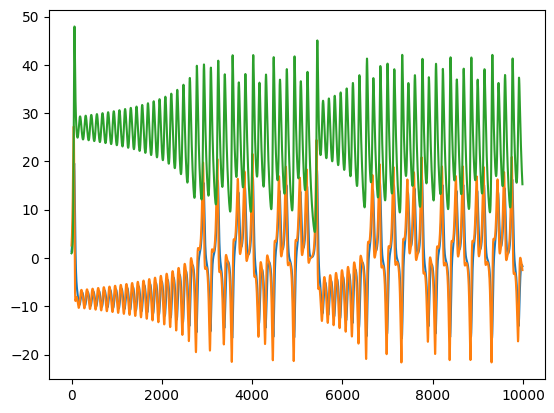

In [22]:
model = Ridge(alpha=alpha)

min_t = nvar.valid_index

states = nvar.transform(X)

X_train = states[:-tau,:]
y_train = X[:, min_t+tau:].T

split = int(0.7 * len(X_train))
X_tr = X_train[:split]
y_tr = y_train[:split]

X_te = X_train[split:]
y_te = y_train[split:]

print(X_tr.shape)

#plt.plot(X_train)
plt.plot(y_train)

model.fit(X_tr, y_tr)

In [23]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_te)

r2 = r2_score(y_te, y_pred)
r2

0.9999875212863231

# Comparaison avec NVAR de reservoirpy

In [24]:
from reservoirpy.nodes import NVAR as ReservoirNVAR
from reservoirpy.nodes import Ridge as ReservoirRidge


In [25]:

X_rpy = X.T
X_rpy_data = X_rpy[:-tau]
y_rpy_data = X_rpy[tau:]

split_py = int(0.7 * len(X_rpy_data))

X_train_py = X_rpy_data[:split_py]
y_train_py = y_rpy_data[:split_py]

X_test_py = X_rpy_data[split_py:]
y_test_py = y_rpy_data[split_py:]

print(X_train_py.shape)


(6993, 3)


In [26]:
nvar_py = ReservoirNVAR(delay=2, order=2, strides=1)
readout = ReservoirRidge(alpha)

model_py = nvar_py >> readout
model_py.fit(X_train_py, y_train_py, warmup=min_t)

Model(NVAR(input_dim:3), Ridge(ridge:1.0, input_dim:27, output_dim:3))

In [27]:
y_pred_py = model_py.predict(X_test_py)

r2_py = r2_score(y_test_py, y_pred_py)
r2_py

0.9999875212956068

In [28]:
y_pred_py.shape

(2997, 3)

In [33]:
delay = 2
strides = [1]
order = 2
update_rate = 1.
alpha=1. # coef du ridge


results_nvar = []
results_py_nvar = []
for tau in range(1, 100):
    # mon modele
    nvar = NVAR(delay, strides, order, update_rate)
    nvar.fit(X)

    states = nvar.transform(X)


    min_t = nvar.valid_index


    states_data = states[:-tau,:]
    y_data = X[:, min_t+tau:].T

    split = int(0.7 * len(X_train))
    X_tr = states_data[:split]
    y_tr = y_data[:split]

    X_te = states_data[split:]
    y_te = y_data[split:]
    
    model = Ridge(alpha)

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)

    results_nvar.append(r2)

    # modele reservoirpy    
    X_rpy = X.T
    X_rpy_data = X_rpy[:-tau]
    y_rpy_data = X_rpy[tau:]

    split_py = int(0.7 * len(X_rpy_data))

    X_train_py = X_rpy_data[:split_py]
    y_train_py = y_rpy_data[:split_py]

    X_test_py = X_rpy_data[split_py:]
    y_test_py = y_rpy_data[split_py:]

    nvar_py = ReservoirNVAR(delay=2, order=2, strides=1)
    readout = ReservoirRidge(alpha)

    model_py = nvar_py >> readout
    model_py.fit(X_train_py, y_train_py, warmup=min_t)   

    y_pred_py = model_py.predict(X_test_py)
    r2_py = r2_score(y_test_py, y_pred_py)
    results_py_nvar.append(r2_py) 


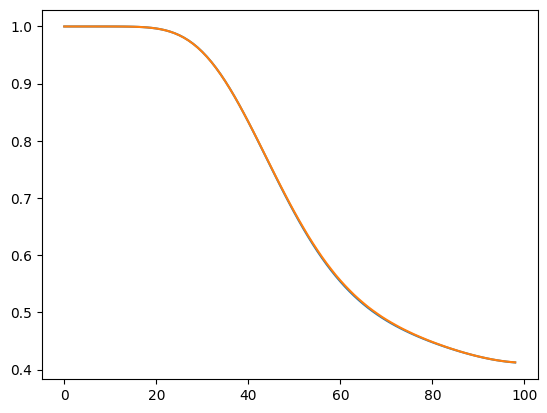

In [34]:
plt.plot(results_nvar)
plt.plot(results_py_nvar)

In [31]:
results_py_nvar, results_nvar

([0.9999998551839505,
  0.9999995604301049,
  0.9999991016983265,
  0.999998525742205,
  0.9999979007506982,
  0.9999972561791083,
  0.9999964989755101,
  0.9999952962224201,
  0.9999928365465046],
 [0.9999998564433711,
  0.9999995635934428,
  0.9999991068530084,
  0.9999985338872858,
  0.9999979095159707,
  0.9999972636685676,
  0.9999965078760127,
  0.9999953010278273,
  0.9999928365415659])